### Part 1 
#### Task 1: Load and Inspect the Diabetic data set

In [1]:
# Load Libraries
import pandas as pd
import numpy as np
# Loading visual libraries later in part 4

In [2]:
# Load Dataset into DataFrame
Diabetic= "diabetic_data.csv"
mapping= "IDS_mapping.csv"
data = pd.read_csv(Diabetic)

# First five rows
print(f"First five rows:\n", data.head(5))

# Data set structure
print(data.info())

# List of columns
print(f"Columns:",data.columns.tolist())

# Number of rows and columns
print(f"\nShape of data set:", data.shape)
print(f"Number of rows:", len(data))
print(f"Number of columns:", len(data.columns))

First five rows:
    encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)    NaN   
1        149190     55629189        Caucasian  Female  [10-20)    NaN   
2         64410     86047875  AfricanAmerican  Female  [20-30)    NaN   
3        500364     82442376        Caucasian    Male  [30-40)    NaN   
4         16680     42519267        Caucasian    Male  [40-50)    NaN   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No   

C:\Users\Dell\AppData\Local\Temp\ipykernel_17528\3253342669.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(Diabetic)


##### There are 101766 rows and 50 columns in the data set.

In [3]:
#Find out what these data columns look like:
print(f"Number of Outpatient", data["number_outpatient"].head(5))
print(f"Number of emergency", data["number_emergency"].head(5))
print(f"Number of inpatient", data["number_inpatient"].head(5))
print(f"Number of diagnoses", data["number_diagnoses"].head(5))

Number of Outpatient 0    0
1    0
2    2
3    0
4    0
Name: number_outpatient, dtype: int64
Number of emergency 0    0
1    0
2    0
3    0
4    0
Name: number_emergency, dtype: int64
Number of inpatient 0    0
1    0
2    1
3    0
4    0
Name: number_inpatient, dtype: int64
Number of diagnoses 0    1
1    9
2    6
3    7
4    5
Name: number_diagnoses, dtype: int64


#### Task 2: Data Cleaning, Analytical Preparation and Feature Creation

#### Selecting the relevant data and making a copy
Only some columns out of the 50 are required for this project. Hence, it is easier to copy the dataframe with only the relevant data than to drop most of the columns. Deep copy was used to prevent alterations to the original dataframe, this is to have the option to add other columns from the original data set if required. This option allows further analysis if needed without starting from scratch.

In [4]:
# data cleaning
# Copilot was used to create the new dataframe - link : https://copilot.microsoft.com/shares/LdksEPFMAvpqqfMh3yETz
cols_to_keep = [
    "encounter_id",
    "patient_nbr",
    "race",
    "gender",
    "age",
    "admission_type_id",
    "medical_specialty",
    "time_in_hospital",
    "num_medications",
    "readmitted",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

df_relevant = data[cols_to_keep].copy(deep=True)


#### Why these columns were kept for data cleaning:
encounter_id = To determine how many encounters a patient has had when grouped with patient nbr.
patient_nbr = To identify whether it is the same patient and not to double count a patient.
race, gender, age = Demographic data to compare other data in age groups, or compare data across genders and race.
admission_type_id = States the type of admission, can group patients accroding to admission types.
medical_specialty = Type of medical care, determines whether it may be diabetes related.
time_in_hospital = Time spent at hospital, can be correlated to readmission time-frames.
num_medications = Patients with more medications could have more underlying conditions, which increases risks for disease/readmittance
readmitted = Yes/No or time until readmitted, this is important to identify patients readmitted within 30 days.
number_diagnoses = Number of diagnoses for the patient. To investigate correlation between number of diagnoses and encounter data. This could give insight into misdiagnoses.

The following data were chosen to look at whether admission history has correlation to time in hospital or readmittance time-frames:
number_outpatient = Number of times the patient received care without being admitted to hospital. 
number_emergency = Number of times the patient has been an emergency patient.
number_inpatient = Number of times the patient has been an inpatient - overnight hospital stay.

### Cleaning the new dataframe

In [5]:
# Cleaning the new dataframe
# Checking for null-values
print (df_relevant.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   encounter_id       101766 non-null  int64 
 1   patient_nbr        101766 non-null  int64 
 2   race               99493 non-null   object
 3   gender             101766 non-null  object
 4   age                101766 non-null  object
 5   admission_type_id  101766 non-null  int64 
 6   medical_specialty  51817 non-null   object
 7   time_in_hospital   101766 non-null  int64 
 8   num_medications    101766 non-null  int64 
 9   readmitted         101766 non-null  object
 10  number_outpatient  101766 non-null  int64 
 11  number_emergency   101766 non-null  int64 
 12  number_inpatient   101766 non-null  int64 
 13  number_diagnoses   101766 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 10.9+ MB
None


Only two columns have NAN/missing values. These are the race and medical specialty columns. Due to the categorical nature of these NAN values, we will simply replace them with a new variable, "Unknown'. By replacing NAN's with unknown, there is less bias introduced into the data set.

In [6]:
# Strip columns and standardise
# # Select only object (string) columns
# df_obj = df_relevant.select_dtypes(['object'])

# # Apply strip and lower to all
# df[df_obj.columns] = df_obj.apply(lambda x: x.str.strip().str.lower())

# # Replace NAN with unknown
# df_replaced= df_obj.fillna("unknown")

# Select only object (string) columns
obj_cols = df_relevant.select_dtypes(include='object').columns

# Strip and standardise text columns
df_relevant[obj_cols] = df_relevant[obj_cols].apply(
    lambda col: col.str.strip().str.title()
)

# Replace missing values with 'unknown'
df_relevant[obj_cols] = df_relevant[obj_cols].fillna("Unknown")


In [7]:
# Check if successful
print(df_relevant.info())
#Changing dataframe name to df_replaced to show unknown values replaced 
df_replaced= df_relevant

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   encounter_id       101766 non-null  int64 
 1   patient_nbr        101766 non-null  int64 
 2   race               101766 non-null  object
 3   gender             101766 non-null  object
 4   age                101766 non-null  object
 5   admission_type_id  101766 non-null  int64 
 6   medical_specialty  101766 non-null  object
 7   time_in_hospital   101766 non-null  int64 
 8   num_medications    101766 non-null  int64 
 9   readmitted         101766 non-null  object
 10  number_outpatient  101766 non-null  int64 
 11  number_emergency   101766 non-null  int64 
 12  number_inpatient   101766 non-null  int64 
 13  number_diagnoses   101766 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 10.9+ MB
None


### A Duplicate check
A basic duplicate check is done on all the columns and only one selected column separately. If a duplicate check were to be done using patient_nbr (patient Id), then multiple duplicates would come up due to one patient have numerous visits. Hence, the only column to check for duplicates is encounter id, there should only be one id per encounter between a patient and medical staff member.

In [8]:
duplicates = df_replaced.duplicated().sum()
print (duplicates)
# Checking encounter id
dup_encounter=df_replaced[df_replaced.duplicated(subset=["encounter_id"])].sum()
print(dup_encounter)

0
encounter_id         0
patient_nbr          0
race                 0
gender               0
age                  0
admission_type_id    0
medical_specialty    0
time_in_hospital     0
num_medications      0
readmitted           0
number_outpatient    0
number_emergency     0
number_inpatient     0
number_diagnoses     0
dtype: object


No duplicates were found in the data frame. The count of rows are still 101766 for all columns and there were no duplicates counted.

#### Appropriate Data Types
Next, not all the data types in the data set are in acceptable formats. The encounter_id and patient_nbr columns are int64 and should be changed to string format to avoid being used in calculations since they are identifiers. To make plotting easier, a new analytical variable will also be added to show the number of encounters per patient.

In [9]:
# Renaming data set
df= df_replaced
# Changing column types
df["encounter_id"] = df["encounter_id"].astype("string")
df["patient_nbr"] = df["patient_nbr"].astype("string")


Age is written in a object format due to being ranges instead of direct values and will not work for binning during plotting. Therefore, the age category will be converted to categorical data but with an order, becoming ordinal data. Also, the age group variables are not suitable because they work from decade to decade (20-30) instead of starting after the decade and ending at he the end (21-30). The problem is, even though the data may not show this due to the set up of age-group categories, the current setup causes multiple people to actually fall into 2 categories if they are on the decades age, eg) Age 30 would be eligible for the 20-30 and 30-40 age categories. Hence, age groups of (decade+1 to next decade) would be a better way to categorise. 

The age groups of the age category will be changed and added into an additional collumn to keep the data integrity. Due to the current method that the age category is set in, it will be hard to change it to the most ideal groups of 5 year intervals which is suggested by most research guidelines. Therefore, I am changing it to the most achievable groupings by keeping the data continous and keeping them in the decade format, just making them more precise:
0-9,
10-19,
20-29,
30-39, 
continues the same way until the last category of 90-100.

Hence, a new  column with the lower bound in the age bracket is added (age_lower column), this is to make new bins with pd.cut for the new age categories(age_group column).

In [10]:
# changing the age groups 
# Extract the lower bound from strings like "20-30"
df["age_lower"] = df["age"].str.extract(r'(\d+)', expand=False).astype(int)

# Define corrected bins
bins = [0,10,20,30,40,50,60,70,80,90,100]
labels = ["0-9","10-19","20-29","30-39","40-49",
          "50-59","60-69","70-79","80-89","90-100"]

df["age_group"] = pd.cut(df["age_lower"], bins=bins, labels=labels, right=False)

#Used Copilot for the code: https://copilot.microsoft.com/shares/qAc8YdcN8iqi26zKsRu3w

In [11]:
#Checking for any unmapped data
df[df["age_group"].isna()]["age_group"].value_counts()

age_group
0-9       0
10-19     0
20-29     0
30-39     0
40-49     0
50-59     0
60-69     0
70-79     0
80-89     0
90-100    0
Name: count, dtype: int64

It will also be easier to use the data if the admission type values were converted to their descriptions. Hence, their descriptions in the IDS_mapping file will be used and these codes will be converted to their description in the data frame. After converting, the data will be changed to a new categorical data type as well sincce it is no longer numercial.


In [12]:
# Creating a dictionary of the data
admission_map = {
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Newborn",
    5: "Not Available",
    6: "NULL",
    7: "Trauma Center",
    8: "Not Mapped"
}
# Mapping the data
df["admission_type"] = df["admission_type_id"].map(admission_map)
# Changing the column type to categorical since it is no longer numerical.
df["admission_type"] = df["admission_type"].astype("category")


In [13]:
#Checking for any unmapped data
df[df["admission_type"].isna()]["admission_type_id"].value_counts()


Series([], Name: count, dtype: int64)

Lastly, it is important to show the number of encounters per patient, this is to know if they have a history to look at. Hence, a new column with the number of encounters for the patient is created.


In [14]:
# Creating a new column for number of encounters
df["encounter_count"] = df.groupby("patient_nbr")["encounter_id"].transform("count")

# Used Copilot for the code: https://copilot.microsoft.com/shares/KYG3u6VvCSMzyYnfzvbSS

In [15]:
#Checking for any unmapped data
df[df["encounter_count"].isna()]["encounter_count"].value_counts()

Series([], Name: count, dtype: int64)

In [16]:
#checking data column types again for any changes required
print(df.head(5))
print (df.info())

  encounter_id patient_nbr             race  gender      age  \
0      2278392     8222157        Caucasian  Female   [0-10)   
1       149190    55629189        Caucasian  Female  [10-20)   
2        64410    86047875  Africanamerican  Female  [20-30)   
3       500364    82442376        Caucasian    Male  [30-40)   
4        16680    42519267        Caucasian    Male  [40-50)   

   admission_type_id         medical_specialty  time_in_hospital  \
0                  6  Pediatrics-Endocrinology                 1   
1                  1                   Unknown                 3   
2                  1                   Unknown                 2   
3                  1                   Unknown                 2   
4                  1                   Unknown                 1   

   num_medications readmitted  number_outpatient  number_emergency  \
0                1         No                  0                 0   
1               18        >30                  0                 0

The cleaned dataset is saved under cleaned_diabetes_data.csv

#### Aggregations for the Visualisations in Part 4

###### Need to make sure all charts are synchronised, therefore making the order for readmitted to be applied to all charts.

In [17]:
readmit_order = ["No", "<30", ">30"]

df["readmitted"] = pd.Categorical(
    df["readmitted"],
    categories=readmit_order,
    ordered=True
)

In [18]:
# Q1 aggregation to find the unique counts of patients per readmitted category.
q1_counts = (
    df.groupby("readmitted")["patient_nbr"]
      .nunique()
      .reset_index(name="patient_count")
)

# Q2 aggregation to find the number of patients readmitted within each category across admission types. 
# Unstack is used to convert it into a table for a stacked bar chart.
q2_counts = (
    df.groupby(["admission_type", "readmitted"])["patient_nbr"]
      .nunique()
      .unstack(fill_value=0)
)

# Q3 aggregation to find the unique number of patients and not encounters per readmission time across genders and age groups
q3_counts = (
    df.groupby(["age_group", "gender", "readmitted"])["patient_nbr"]
      .nunique()
      .reset_index()
)

# Q4 and Q5 do not require aggregations for their visualisations

# Q6 requires the mean number of medications and grouping of the readmitted categories with different races show how these averages change across these groups.
q6_means = (
    df.groupby(["readmitted", "race"])["num_medications"]
      .mean()
      .reset_index(name="avg_num_medications")
)

# Q7 requires looking at unique patients, therefore, we first need the unique patients readmitted within 30 days only, to be able to count the encounters for each patient.
patient_level = (
    df.groupby("patient_nbr")
      .agg(
          encounters=("encounter_id", "nunique"),
          early_readmit=("readmitted", lambda x: (x == "<30").any())
      )
      .reset_index()
)
# Q7 can now be answered by aggregating the mean which is a simple way to find the proportion for our plot.
q7_prop = (
    patient_level.groupby("encounters")["early_readmit"]
      .mean()
      .reset_index(name="prop_early_readmission")
)
# converting proportions to percentages
q7_prop["percent"] = q7_prop["prop_early_readmission"] * 100


q8_counts = (
    df["medical_specialty"]
      .value_counts(dropna=False)
      .reset_index(name="count")
      .rename(columns={"index": "medical_specialty"})
)

# Applying this to ensure even after grouping the order for readmitted remains
for d in [q1_counts, q3_counts, q6_means]:
    if "readmitted" in d.columns:
        d["readmitted"] = pd.Categorical(
            d["readmitted"],
            categories=readmit_order,
            ordered=True
        )



C:\Users\Dell\AppData\Local\Temp\ipykernel_17528\636660800.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("readmitted")["patient_nbr"]
C:\Users\Dell\AppData\Local\Temp\ipykernel_17528\636660800.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["admission_type", "readmitted"])["patient_nbr"]
C:\Users\Dell\AppData\Local\Temp\ipykernel_17528\636660800.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this 

In [19]:
# saving the data to be used for part 4 
v_data = df.to_csv('cleaned_diabetes_data.csv', index=False)

### Part 2
#### Task 3: Visual Analysis Planning
##### Question 1: What is the distribution of the readmission category, with particular focus on whether a patient was readmitted within 30 days of discharge?
1. Descriptive - we are looking at the data and not looking for insights.
2. Bar Chart - show counts
3. The count of patients readmitted per day within a 30 day period. So the *readmitted* attribute and count of *patient_nbr* attributes will be used.
4. A bar chart will show the frequency of readmitted patients per unique readmitted group which is a categorical attribute. This will help to compare numbers/counts of early readmittance to other outcomes, focusing on the 30 day readmittance category.
##### Question 2: How does the readmission category vary by admission type? In particular, which admission types have a higher proportion of early readmissions?
1. Descriptive - only looking at the data and comparing, we are not looking for new insights.
2. Stacked Bar Chart
3. The patient_nbr, readimitted and admission_type (newly made column) will be used.
4. A stacked bar chart shows how a second categorical variable divides each group. Therefore, a stacked bar chart can display the counts of readmitted patients per day and show which proportion consists of early readmissions. Using this chart type, it will be easier to compare proportions of day 1 emergency admissions to day 15 of emergency admissions.
##### Question 3: How does the readmission category vary across age group and gender? 
1. Descriptive - comparing the data and not looking into why it varies.
2. Facet Grid - multiple grouped bar charts
3. The attributes to be used are the gender, age_group (new column) and readmitted columns.
4. The attributes selected for this question have many categories and a wide age group selection. A facet grid is ideal to compare readmission times across age groups and splitting it into three plots for showing the differences across genders. Grouped bar charts are ideal for showing how total numbers of patients vary across multiple categories. Hence, using a facet grid makes comparison easy.
##### Question 4: How does time in hospital vary across readmission categories? In particular, do patients readmitted within 30 days tend to have different lengths of stay? 
1. Descriptive - we are comparing the data and how it changes but not why it does change.
2. Box plot
3. The attributes to be used include the readmittted and time_in_hospital columns.
4. The box plot shows the distribution of time spent in hospital across the different readmission catgories and can show any differences in median or variability between patients readmitted within 30 days or 15 days. Outliers and the median can be used to see if patients readmitted within 30 days have different lengths in stay, by comparing them to the mean. Hence, a box plot shows these clearly.
##### Question 5: How does the distribution of the number of medications vary by readmission category?
1. Descriptive - comparing data distribution which is still descriptive.
2. Violin plot
3. The num_medications and readmitted attributes will be used.
4. A violin plot compares the full distribution and density of the number of medication across readmission categories. It is perfect to compare the numerical (num_medications) and categorical (readmitted) attributes for this question. A facet grid could also be used by showing mutiple histograms for the different readmission categories but a violin plot is more compact and simpler to understand for this question.
##### Question 6: How do treatment-intensity patterns, as measured by the average number of medications, vary across readmission categories and racial groups? 
1. Descriptive - we are comparing patterns across data groups but not looking for insights or mechanisms on what effects it.
2. Grouped Bar Chart
3. The num_medications, race and readmitted attributes will be used. They were prepared in part 1 for the graph by using aggregations.
4. The average number of medications for each readmission category can be compared and for different racial groups. Grouped bar charts are great for comparing averages across subgroups like races. The grouped bar charts also show patterns very well, which we want to see in this visualisation (treatment-intensity patterns). A stacked bar chart would not work due to being used for proportions or distributions and not averages.
##### Question 7: How does the proportion of early readmission vary by number of encounters per patient? 
*(This visualisation must be based on unique patients rather than on encounter-level rows.)*
1. Descriptive - we are only comparing the data.
2. Bar chart - showing proportion
3. The readmitted, patient_nbr and encounter_id attributes are used. They are prepared for the graph in part 1 using aggregates and grouping.
4. Since we want to show the proportion, a pie chart or bar chart would show this the best. Due to the wide variety of encounters among patients, the groups represented is too big for a pie chart and will be better represented on a bar chart. 
##### Question 8: Which medical specialty most frequently admits these patients? 
*(For this visualisation, you may exclude missing, unknown, or invalid medical specialty values, provided that your decision is clearly justified and documented.)*
1. Descriptive - we are comparing data across specialties and not answering why, therefore, making it descriptive as well.
2. Bar Chart - showing counts
3. The medical_speciality attibute was counted. (So we are looking at encounters per medical specialty and not patients)
4. Bar charts are great for comparing numbers/counts across categories. Also, there are many medical specialty's to compare, so a bar graph is able to show all these specialty's.

#### Task 4: Visualisation Construction

In [20]:
# importing visualisation libraries
import seaborn as sns
import matplotlib.pyplot as plt
# importing new data
df= pd.read_csv('cleaned_diabetes_data.csv')

##### Question 1: Bar Chart/Plot

I chose the "Paired" palette to draw attention to the readmitted within 30 days category which is the focus.

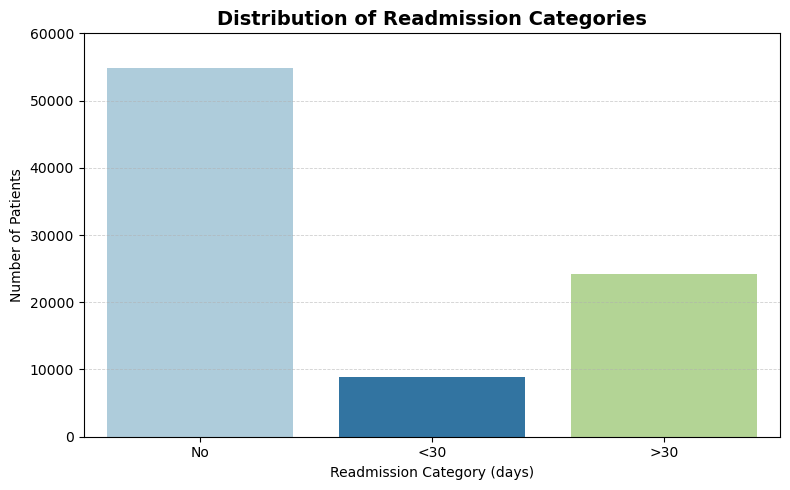

In [21]:
# Question 1
# Barchart for showing the distribution of patients readmitted within 30 days.
plt.figure(figsize=(8, 5))
sns.barplot(data=q1_counts, x="readmitted", y="patient_count", palette="Paired", hue="readmitted", legend=False)

plt.title("Distribution of Readmission Categories", fontsize=14, fontweight='bold')
plt.xlabel("Readmission Category (days)")

plt.ylabel("Number of Patients")
plt.ylim(0,60000)
# Light grid behind bars
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)


plt.tight_layout()
plt.show()


##### Question 2 Visualisation: Stacked Bar Chart
I chose "Set2" for the colormap which highlights the admitted within 30 days category. I also tried a log scale and it unfortunately did show more data but also made the stacking look more similar and hard to distinguish. Hence, I left it this way, because although the Newborn and Trauma admission values are missing, they did not contribute to the 30 day readmission focus when in the log scale format.

<Figure size 1000x600 with 0 Axes>

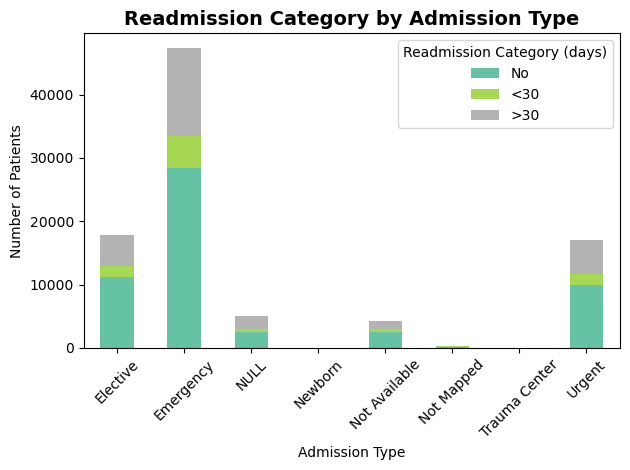

In [22]:
# Question 2 Visual
# Group and reshape the data
plt.figure(figsize=(10, 6))
q2_counts.plot(kind="bar", stacked=True, colormap="Set2")
#setting title and axes
plt.title("Readmission Category by Admission Type", fontsize=14, fontweight='bold')

plt.xlabel("Admission Type")
plt.xticks(rotation=45) # making x axis more readable

plt.ylabel("Number of Patients")
# plt.yscale('log') # makes the proportions hard to see.
# plt.ylim(0,50000)


plt.legend(title="Readmission Category (days)")
plt.tight_layout()
plt.show()



##### Question 3 Visualisation: Facet Grid of Bar Charts
Using the "Paired" color palette again to highlight the patients admitted under 30 days. Also, I used a logarithmic scale to show all the data without distorting the comparisons by making them proportionate. Without the log scale, the Unknown/invalid genders graph looks empty. 

C:\Users\Dell\AppData\Local\Temp\ipykernel_17528\1613905050.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\Dell\AppData\Local\Temp\ipykernel_17528\1613905050.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\Dell\AppData\Local\Temp\ipykernel_17528\1613905050.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


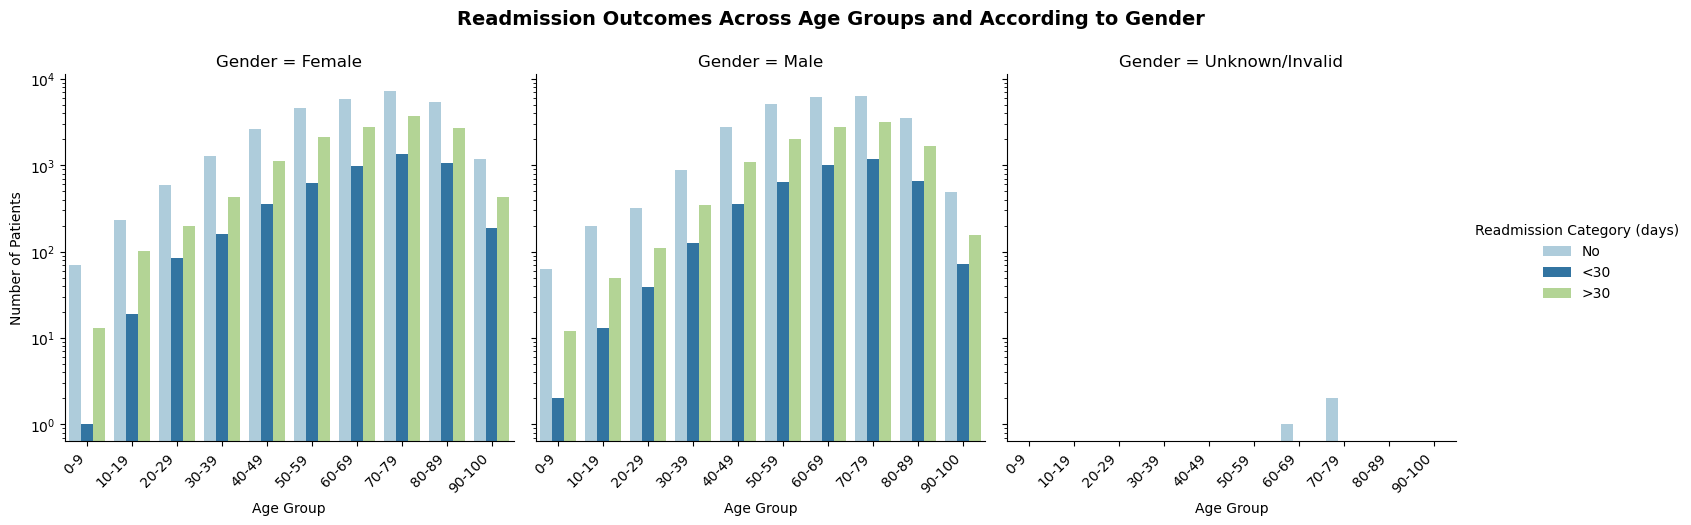

In [23]:
# Question 3 

g = sns.FacetGrid(
    q3_counts,
    col="gender",
    height=5,
    aspect=1
    #sharey=False  
)
g.map_dataframe(sns.barplot, x="age_group", y="patient_nbr", hue="readmitted", palette="Paired")
g.set(yscale="log") #Added to show all data in the most accurate way

g.add_legend(title="Readmission Category (days)")
g.set_axis_labels("Age Group", "Number of Patients")
#rotate x-axis labels for easier reading
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Readmission Outcomes Across Age Groups and According to Gender", fontsize=14, fontweight='bold')


# Make the bars for facet grid - "unknown" more visible
# for ax in g.axes.flat:
#     for p in ax.patches:
#         height = p.get_height()
#         if height > 0:
#             ax.annotate(
#                 int(height),
#                 (p.get_x() + p.get_width() / 2, height),
#                 ha="center", va="bottom", fontsize=9
#             ) #This option is a bit messy


for ax in g.axes.flat:
    title = ax.get_title()
    ax.set_title(title.title())

plt.show()


##### Question 4 Visualisation: Box Plot
Selected the "deep" palette and left the boxes unfilled to see the mean, median and quartile ranges properly.

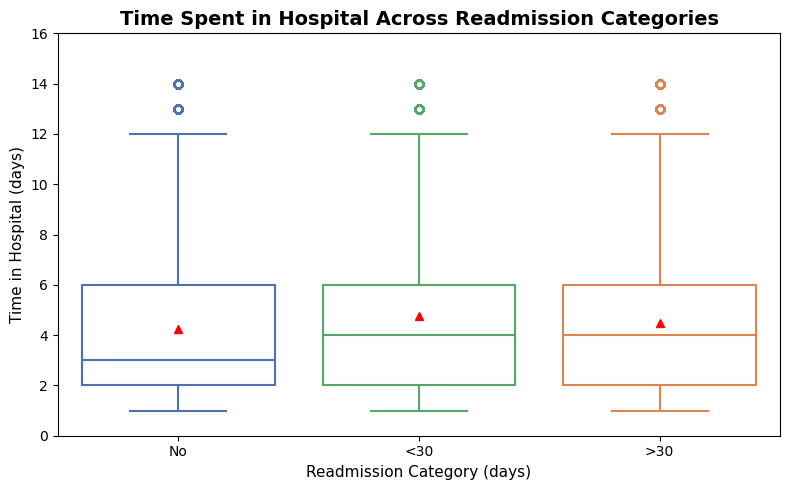

In [24]:
# Question 4 Visualisation

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, 
            x="readmitted", y="time_in_hospital",
            hue="readmitted", palette="deep", fill=False, order= readmit_order, 
            showmeans=True, meanprops={"markerfacecolor":"red",
                                        "markeredgecolor":"red"})
# setting the title and axes
plt.title("Time Spent in Hospital Across Readmission Categories", fontsize=14, fontweight='bold')
plt.xlabel("Readmission Category (days)", size=11)
#Setting the y label
plt.ylabel("Time in Hospital (days)", size=11)
plt.ylim(0,16) # making the axis more readable
plt.tight_layout()
plt.show()


##### Question 5 Visualisation: Violin Plot

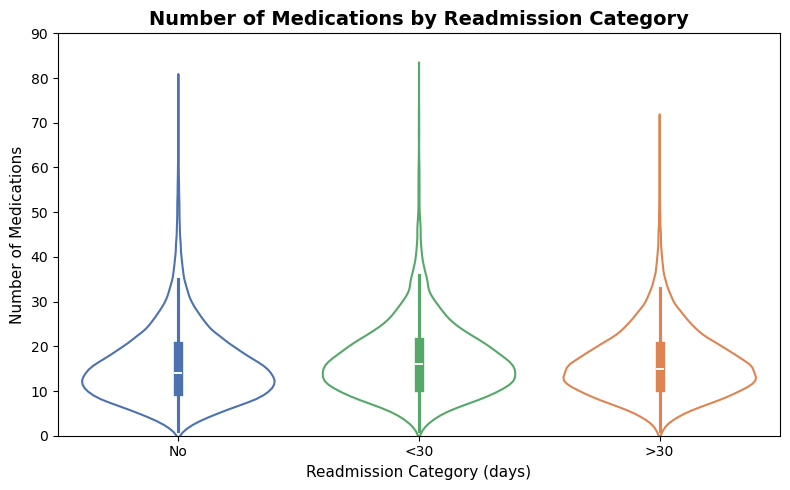

In [25]:
# Question 5 Visualisation
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="readmitted", y="num_medications", palette="deep", hue="readmitted", legend=False, fill=False, order=readmit_order)

plt.title("Number of Medications by Readmission Category", fontsize=14, fontweight='bold')
plt.xlabel("Readmission Category (days)", fontsize=11)
plt.ylabel("Number of Medications", fontsize=11)
plt.ylim(0, 90)
plt.tight_layout()
plt.show()


##### Question 6 Visualisation: Grouped Bar Chart 
The "Paired" colour palette separated the different bars the most, making it easy to distinguish different races.

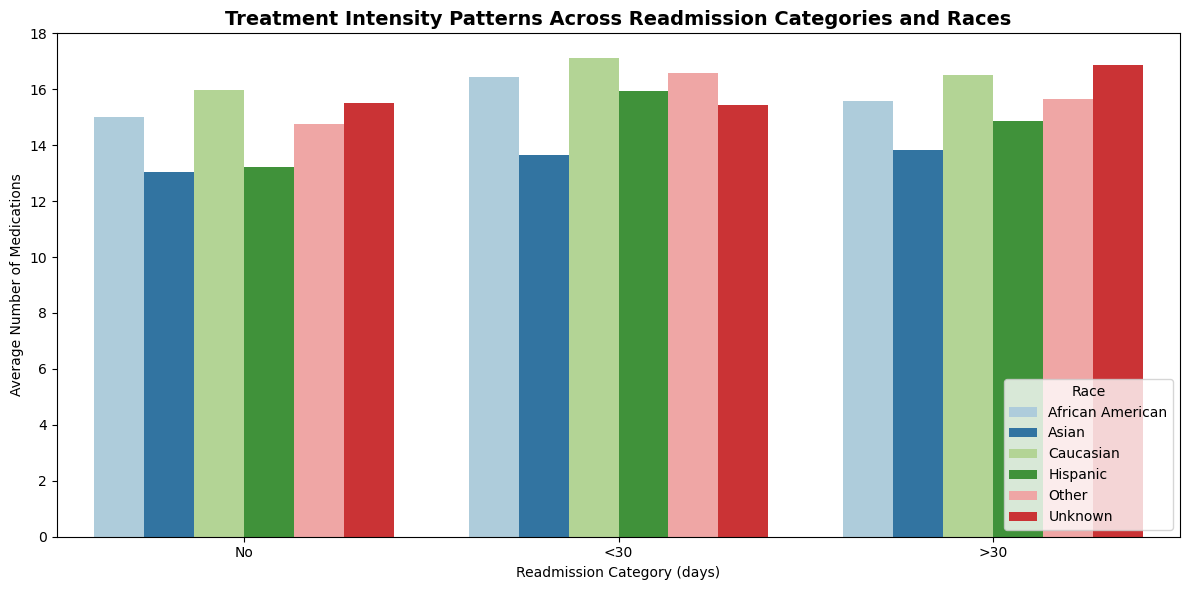

In [26]:
# Question 6 Visualisation

# Fixing labels for legend
rename_map = {
    "Africanamerican": "African American",
    "Asian": "Asian",
    "Caucasian": "Caucasian",
    "Hispanic": "Hispanic",
    "other": "Other",
    "unknown": "Unknown"
}

plt.figure(figsize=(12, 6))

# Plotting graph
sns.barplot(
    data=q6_means,
    x="readmitted",
    y="avg_num_medications",
    hue="race",
    palette="Paired"
)

# Create legend FIRST
leg = plt.legend(title="Race", loc='lower right')

# Then rename legend labels
for text in leg.get_texts():
    old = text.get_text()
    text.set_text(rename_map.get(old, old))

# Titles and labels
plt.title("Treatment Intensity Patterns Across Readmission Categories and Races",
          fontsize=14, fontweight='bold')
plt.xlabel("Readmission Category (days)")
plt.ylabel("Average Number of Medications")
plt.ylim(0, 18)

plt.tight_layout()
plt.show()




##### Question 7 Visualisation: Bar Chart Displaying Proportion
The "Paired" palette shows the proportions vividly and is coherent with all the other graphs, making it a more ideal choice.

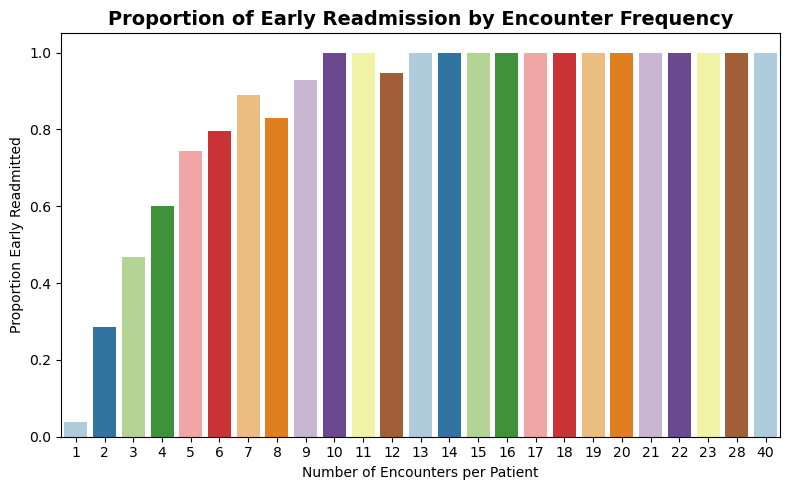

In [27]:
# Question 7 Visualisation
plt.figure(figsize=(8, 5))
sns.barplot(data=q7_prop, x="encounters", y="prop_early_readmission", palette="Paired", hue="encounters", legend=False)

plt.title("Proportion of Early Readmission by Encounter Frequency",fontsize=14, fontweight='bold')
plt.xlabel("Number of Encounters per Patient")
plt.ylabel("Proportion Early Readmitted")
plt.tight_layout()
plt.show()


##### Quesion 8 Visualisation: Count Plot
I kept the unknown specialities to show that a lot of data needs to be allocated or followed up for this section. It also indicates many diabetic people may have entered hospital without knowledge of the specialist they saw or required.

C:\Users\Dell\AppData\Local\Temp\ipykernel_17528\940069574.py:10: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 10^10)


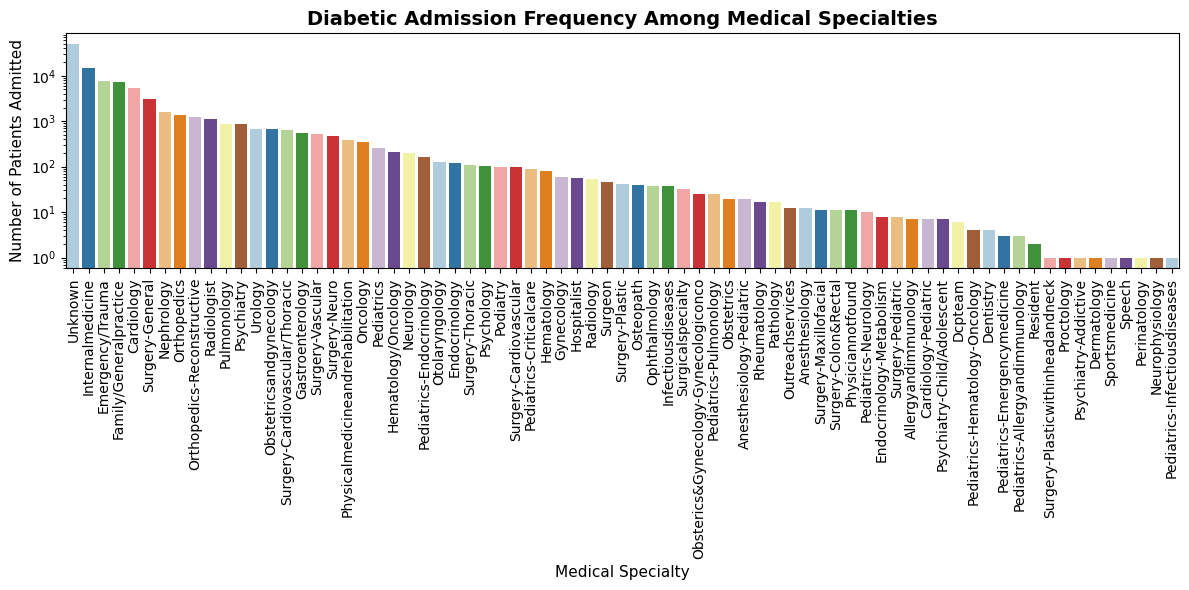

In [28]:
# Question 8 Visualisation
plt.figure(figsize=(12, 6))
sns.barplot(data=q8_counts, x="medical_specialty", y="count", palette="Paired", hue="medical_specialty", legend=False)

plt.title("Diabetic Admission Frequency Among Medical Specialties", fontsize=14, fontweight='bold')
plt.xlabel("Medical Specialty", fontsize=11)
# making the data more readible by making it a log scale and setting new limits
plt.ylabel("Number of Patients Admitted", fontsize=11)
plt.yscale('log')
plt.ylim(0, 10^10)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

